### this notebooks attempt use the autoencoder + HDSCAN to see how results show

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_theme(style='darkgrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
raw_data = pd.read_csv('../data/processed/mhd_ch4_ml_v2.csv')
raw_data.head(20)

/tmp/ipykernel_51388/2919345968.py:1: DtypeWarning: Columns (37) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_data = pd.read_csv('../data/processed/mhd_ch4_ml_v2.csv')


,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal,year,month,day,hour,minute,seconds,psamp_roll_mean_10,pamb_roll_mean_10,pflow_roll_mean_10,tmod_roll_mean_10,psamp_roll_mean_100,pamb_roll_mean_100,pflow_roll_mean_100,tmod_roll_mean_100,psamp_roll_std_10,pamb_roll_std_10,pflow_roll_std_10,CH4_rt_roll_std_10,psamp_roll_std_100,pamb_roll_std_100,pflow_roll_std_100,CH4_rt_roll_std_100,psamp_diff_1,pflow_diff_1,CH4_area_diff_1,psamp_lag_1,pflow_lag_1
0,940216,142900,air,10m,G-024,3,10.0,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,14,29,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,940216,144900,air,10m,G-024,3,10.0,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,14,49,0,761.100000,761.100000,841.900000,40.000000,761.100000,761.100000,841.900000,40.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,761.10,841.9
2,940216,150900,air,10m,G-024,3,10.0,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,0.384554,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,15,9,0,761.085000,761.150000,841.150000,40.000000,761.085000,761.150000,841.150000,40.000000,0.021213,0.070711,1.060660,0.000000,0.021213,0.070711,1.060660,0.000000,-0.03,-1.5,0.0,761.07,840.4
3,940216,152900,air,10m,G-024,3,10.0,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,False,0.0,0.142279,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,15,29,0,761.053333,761.066667,840.566667,40.003333,761.053333,761.066667,840.566667,40.003333,0.056862,0.152753,1.258306,63.393060,0.056862,0.152753,1.258306,63.393060,-0.08,-1.0,496440.0,760.99,839.4
4,940216,180000,air,10m,G-024,3,10.0,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,18,0,0,761.030000,761.025000,840.325000,40.002500,761.030000,761.025000,840.325000,40.002500,0.065828,0.150000,1.135415,59.379542,0.065828,0.150000,1.135415,59.379542,-0.03,0.2,569542.0,760.96,839.6
5,940216,182000,air,10m,G-024,3,10.0,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216182000,1994-02-16 18:20:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,18,20,0,760.968000,760.940000,841.340000,40.002000,760.968000,760.940000,841.340000,40.002000,0.149900,0.230217,2.473459,56.282431,0.149900,0.230217,2.473459,56.282431,-0.24,5.8,-1065982.0,760.72,845.4
6,940216,184000,air,10m,G-024,3,

20 mins for noe data?

In [3]:
raw_data.tail()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal,year,month,day,hour,minute,seconds,psamp_roll_mean_10,pamb_roll_mean_10,pflow_roll_mean_10,tmod_roll_mean_10,psamp_roll_mean_100,pamb_roll_mean_100,pflow_roll_mean_100,tmod_roll_mean_100,psamp_roll_std_10,pamb_roll_std_10,pflow_roll_std_10,CH4_rt_roll_std_10,psamp_roll_std_100,pamb_roll_std_100,pflow_roll_std_100,CH4_rt_roll_std_100,psamp_diff_1,pflow_diff_1,CH4_area_diff_1,psamp_lag_1,pflow_lag_1
817950,260518,65300,std,J-286,J-286,3,0.0,40.0,22.06,NaN,813.5,752.32,NaN,752.4,77.8,3.98,133194.0,131007.0,0.50,73.0,99.8,99999.0,62297.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.649,NaN,2015.923,,,A,,0,0,0,260518065300,2026-05-18 06:53:00,False,False,False,False,26.8,False,-37702.0,1.016694,2026-05-18 06:13:00,2400.0,1,0,0,0,0,0,2026-04-28 06:18:00,1730100.0,2026,5,18,6,53,0,752.322,752.33,811.07,40.0,752.7259,752.700,811.938,40.0,0.100532,0.176698,2.445881,58.760792,0.525492,0.535601,2.558360,20.930976,0.01,-4.8,182060.0,752.26,808.6
817951,260518,71300,air,9m,J-286,1,9.0,40.0,22.32,NaN,808.6,752.28,NaN,752.2,79.0,4.57,160607.0,508996.0,0.46,73.0,102.0,99999.0,64464.0,1.02271,1.00491,1.00491,1.0227,1.0049,0.9981,1.02271,1.00491,1.00491,2061.71,2025.82,2025.82,3.649,3.666,2015.923,,,A,,0,0,0,260518071300,2026-05-18 07:13:00,False,False,False,False,29.0,False,-35535.0,0.315537,2026-05-18 06:13:00,3600.0,0,1,0,0,0,0,2026-04-28 06:18:00,1731300.0,2026,5,18,7,13,0,752.309,752.31,811.05,40.0,752.7119,752.686,811.921,40.0,0.089994,0.152388,2.422694,55.450498,0.517325,0.524745,2.542062,20.994550,0.06,4.9,-51053.0,752.32,813.5
817952,260518,73300,std,J-286,J-286,3,0.0,40.0,22.19,NaN,813.1,752.27,NaN,752.4,80.6,5.17,180892.0,882007.0,0.47,73.0,109.2,84204.0,66307.0,1.07106,1.34773,1.34773,1.0712,1.3480,1.0953,1.07106,1.34773,1.34773,2159.17,2716.92,2716.92,4.605,NaN,2015.923,,,A,,0,0,0,260518073300,2026-05-18 07:33:00,False,False,False,False,36.2,False,-17897.0,0.205091,2026-05-18 06:53:00,2400.0,1,0,0,0,0,0,2026-04-28 06:18:00,1732500.0,2026,5,18,7,33,0,752.294,752.28,811.00,40.0,752.6971,752.673,811.902,40.0,0.079470,0.139841,2.472066,51.803578,0.508126,0.520461,2.559829,21.047673,-0.04,-4.9,377989.0,752.28,808.6
817953,260518,75300,air,9m,J-286,1,9.0,40.0,22.10,NaN,808.2,752.13,NaN,752.2,80.4,5.01,186959.0,856303.0,0.41,73.0,106.6,87769.0,65923.0,0.97017,0.83156,NaN,0.9701,0.8315,0.9433,0.97017,0.83156,NaN,1955.78,1676.37,NaN,4.605,NaN,2015.923,*,*,A,,1,1,1,260518075300,2026-05-18 07:53:00,False,False,False,False,33.6,False,-21846.0,0.218333,2026-05-18 06:53:00,3600.0,0,1,0,0,0,0,2026-04-28 06:18:00,1733700.0,2026,5,18,7,53,0,752.272,752.27,810.96,40.0,752.6809,752.659,811.881,40.0,0.039665,0.125167,2.429998,46.793428,0.495375,0.508532,2.541045,21.088841,-0.01,4.5,373011.0,752.27,813.1
817954,260518,81300,std,J-286,J-286,3,0.0,40.0,22.23,NaN,813.3,752.09,NaN,752.0,82.0,5.46,204547.0,1177596.0,0.43,73.0,115.2,75876.0,68601.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.873,NaN,2015.923,,,A,,0,0,0,260518081300,2026-05-18 08:13:00,False,False,False,False,42.2,False,-7275.0,0.173699,2026-05-18 07:33:00,2400.0,1,0,0,0,0,0,2026-04-28 06:18:00,1734900.0,2026,5,18,8,13,0,752.249,752.27,810.90,40.0,752.6633,752.643,811.881,40.0,0.048637,0.125167,2.495774,40.690600,0.483096,0.497317,2.541045,21.130081,-0.14,-4.9,-25704.0,752.13,808.2


20 mins one data point

In [4]:
data = raw_data.copy()

# the latetst year shouldn't be used
data = data.drop(data[data['year']==2026].index)
data.tail()

In [5]:
data['type'].unique()

array(['air', 'std', 'tank', 'tank100', 'cal560', 'cal660', 'cal860',
       'cal960', 'cal1060', 'blank', 'labair', 'cal15', 'cal30', 'cal45',
       'cal60', 'cal75', 'cal90', 'cal105', 'cal120', 'cal135', 'cal150',
       'cal165', 'cal180', 'cal200', 'cal225', 'cal250', 'cal300',
       'cal500', 'cal', '-'], dtype=object)

In [6]:
data['sample'].unique()

array(['10m', 'G-024', 'BOC-49177', 'G-028', 'UZA26862', 'S-003', 'G-032',
       'S-004', 'H-005', 'H-004', 'H-006D', 'H-006', 'MRF-S', 'MRF-D',
       'H-003', 'CO-001', 'CLM-005557', 'G-036', 'BOC-49177D', 'CO-001D',
       'G-037', 'H-007', 'S160-H09', 'S160-H05', 'HFD-005', 'H-008D',
       'H-008', 'G-041', 'CO1', 'J-007', 'H-009', 'M-001', 'M-002',
       'H-009D', 'H-010', 'zeroair', 'H-011', 'J-012', 'M-005', 'U.Leeds',
       'J-016', 'H-012', 'Bris1', 'G-050', 'G-055', 'H-013', 'H-014',
       'M-006', 'B-003', 'M-007', 'J-020', 'H-015', 'BRW1', 'ALM064959',
       'HD-007', 'MD-007-6', 'MD-007-4', 'MD-007-3', 'MD-007-2',
       'N2_generator', 'J-025', 'H-016', 'FA01469', 'FA01467', 'FA01477',
       'M-008', 'G-064', 'H-017', 'H-018', 'M-009', 'Zero_27100', 'H-019',
       'H-020', 'J-030', 'CA03255', 'CA03233', 'CA03229', 'CA03220',
       'CA02964', 'UAN990635', 'UAN990624', 'UAN990621', 'UAN990629',
       'UAN990630', 'UAN990622', 'UAN990625', 'UAN990620', 'UAN990634',

##### 抽樣

In [7]:
sampled = []

for y in sorted(data['year'].unique()):
    one_year = data[data['year']==y]
    one_week = one_year.sample(frac=7*24*3 / len(one_year), random_state=42) # 20 mins noe data -> a week ->504 data points
    sampled.append(one_week)

df_sample = pd.concat(sampled).reset_index(drop=True)
df_sample.head()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal,year,month,day,hour,minute,seconds,psamp_roll_mean_10,pamb_roll_mean_10,pflow_roll_mean_10,tmod_roll_mean_10,psamp_roll_mean_100,pamb_roll_mean_100,pflow_roll_mean_100,tmod_roll_mean_100,psamp_roll_std_10,pamb_roll_std_10,pflow_roll_std_10,CH4_rt_roll_std_10,psamp_roll_std_100,pamb_roll_std_100,pflow_roll_std_100,CH4_rt_roll_std_100,psamp_diff_1,pflow_diff_1,CH4_area_diff_1,psamp_lag_1,pflow_lag_1
0,940527,175100,air,10m,G-024,3,10.0,40.00,24.90,NaN,846.1,763.09,NaN,763.2,96.0,7.37,182533.0,1456423.0,1.06,83.6,131.0,28332.0,28260.0,1.09463,1.09310,1.09463,1.0947,1.0931,0.9982,1.09463,1.09310,1.09463,1852.65,1850.05,1852.65,2.922,3.199,1692.489,,,,,0,0,0,940527175100,1994-05-27 17:51:00,False,False,False,False,47.4,False,-72.0,0.125330,1994-05-27 16:51:00,3600.0,0,1,0,0,0,0,1994-05-22 22:06:00,416700.0,1994,5,27,17,51,0,763.218,763.19,845.16,40.000,761.5158,761.549,844.680,40.0011,0.118678,0.119722,0.992416,0.327278,1.566711,1.551115,1.814198,46.863926,0.00,0.6,-131646.0,763.06,845.2
1,941113,700,air,10m,G-032,3,10.0,39.99,22.16,NaN,830.4,748.80,NaN,748.7,97.2,7.60,177656.0,1467563.0,1.07,84.6,132.8,30322.0,30429.0,1.08461,1.08554,1.08461,1.0844,1.0854,0.9997,1.08461,1.08554,1.08461,1821.97,1823.54,1821.97,2.642,2.866,1679.84,,,,,0,0,0,941113000700,1994-11-13 00:07:00,False,False,False,False,48.2,False,107.0,0.121055,1994-11-12 23:07:00,3600.0,0,1,0,0,0,0,1994-11-06 21:59:00,526080.0,1994,11,13,0,7,0,750.490,750.44,831.25,39.999,750.6768,750.686,831.807,40.0003,0.763908,0.780598,1.081409,0.329309,1.718967,1.712817,2.136326,0.314466,-0.26,-0.7,-119037.0,749.21,829.9
2,941212,134000,std,G-032,G-032,1,0.0,40.00,22.01,NaN,858.6,763.04,NaN,763.1,96.8,7.67,167048.0,1393000.0,1.10,84.2,132.4,30800.0,30942.0,0.99970,0.99988,0.99970,0.9997,0.9999,1.0001,0.99970,0.99988,0.99970,1679.33,1679.63,1679.33,2.750,NaN,1679.84,,,,,0,0,0,941212134000,1994-12-12 13:40:00,False,False,False,False,48.2,False,142.0,0.119920,1994-12-12 13:00:00,2400.0,1,0,0,0,0,0,1994-12-11 22:20:00,55200.0,1994,12,12,13,40,0,762.413,762.48,847.72,40.000,767.2839,757.900,845.810,40.0007,0.397633,0.379473,10.400620,0.350238,75.083295,2.267602,9.819405,0.406706,0.08,-19.1,117449.0,762.94,839.1
3,941209,195700,std,G-032,G-032,1,0.0,40.01,21.68,NaN,849.4,752.77,NaN,752.8,97.2,7.63,165570.0,1370716.0,1.06,84.6,132.6,30296.0,30399.0,1.00244,1.00026,1.00244,1.0022,1.0000,0.9993,1.00244,1.00026,1.00244,1683.95,1680.28,1683.95,2.641,NaN,1679.84,,,,,0,0,0,941209195700,1994-12-09 19:57:00,False,False,False,False,48.0,False,103.0,0.120791,1994-12-09 19:17:00,2400.0,1,0,0,0,0,0,1994-12-04 21:52:00,425100.0,1994,12,9,19,57,0,752.770,752.79,838.24,39.999,747.2219,747.305,831.567,40.0003,0.136707,0.119722,11.315103,0.411501,4.731335,4.700062,7.591037,0.350301,0.02,-20.6,107834.0,752.96,828.3
4,940715,230800,air,10m,G-028,3,10.0,40.00,21.27,NaN,847.1,766.91,NaN,767.1,97.8,7.55,182841.0,1495118.0,1.06,85.2,133.2,30346.0,30454.0,1.07481,1.07632,1.07481,1.0747,1.0762,1.0017,1.07481,1.07632,1.07481,1797.87,1800.38,1797.87,3.162,3.399,1672.724,,,,,0,0,0,940715230800,1994-07-15 23:08:00,False,False,False,False,48.0,False,108.0,0.122292,1994-07-15 22:08:00,3600.0,0,1,0,0,0,0,1994-07-10 22:02:00,435960.0,1994,7,15,23,8,0,766.834,766.84,853.53,40.001,764.1732,764.209,850.673,40.0004,0.166946,0.171270,5.557188,0.267499,1.960295,1.950037,6.366910,0.327735

In [8]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16632 entries, 0 to 16631
Data columns (total 92 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    16632 non-null  int64  
 1   time                    16632 non-null  int64  
 2   type                    16632 non-null  object 
 3   sample                  16632 non-null  object 
 4   standard                16632 non-null  object 
 5   port                    16632 non-null  int64  
 6   ht                      16632 non-null  float64
 7   tmod                    14410 non-null  float64
 8   tamb                    14410 non-null  float64
 9   lab_temp                0 non-null      float64
 10  pflow                   16593 non-null  float64
 11  psamp                   16594 non-null  float64
 12  ploop                   0 non-null      float64
 13  pamb                    16587 non-null  float64
 14  CH4_rt                  16602 non-null

In [9]:
# check data amount
print(16128/(24*7*3))
print(2025-1994+1)

32.0
32


In [10]:
df_sample['type'].unique()

array(['air', 'std', 'cal960', 'cal860', 'cal660', 'tank', 'cal560',
       'cal1060', 'blank', 'labair', 'cal250', 'cal60', 'cal'],
      dtype=object)

In [11]:
df_sample[df_sample['type']=='blank']

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal,year,month,day,hour,minute,seconds,psamp_roll_mean_10,pamb_roll_mean_10,pflow_roll_mean_10,tmod_roll_mean_10,psamp_roll_mean_100,pamb_roll_mean_100,pflow_roll_mean_100,tmod_roll_mean_100,psamp_roll_std_10,pamb_roll_std_10,pflow_roll_std_10,CH4_rt_roll_std_10,psamp_roll_std_100,pamb_roll_std_100,pflow_roll_std_100,CH4_rt_roll_std_100,psamp_diff_1,pflow_diff_1,CH4_area_diff_1,psamp_lag_1,pflow_lag_1
2499,980728,152900,blank,G-050,J-025,7,0.0,40.00,21.06,NaN,815.3,754.96,NaN,754.9,97.8,8.47,140843.0,1316734.0,1.11,84.8,135.0,23139.0,23483.0,0.93348,0.93401,0.93348,0.9333,0.9339,1.0005,0.93348,0.93401,0.93348,1714.57,1715.54,1714.57,3.368,NaN,1836.745,,,,,0,0,0,980728152900,1998-07-28 15:29:00,False,False,False,False,50.2,False,344.0,0.106964,1998-07-28 14:29:00,3600.0,0,0,0,1,0,0,1998-07-26 02:46:00,218580.0,1998,7,28,15,29,0,755.255,760.38,804.13,40.000,754.9381,755.466,803.867,39.9995,0.235289,16.136832,3.969901,0.315524,1.163052,5.261317,3.756531,0.306555,0.06,7.9,3326.0,755.17,807.6
2852,991104,135500,blank,Zero_27100,J-035,11,0.0,NaN,NaN,NaN,795.7,749.71,NaN,749.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.0000,0.0000,0.0000,0.00000,0.00000,0.00000,0.00,0.00,0.00,9.157,NaN,1839.142,,,,,0,0,0,991104135500,1999-11-04 13:55:00,False,False,True,True,0.0,False,0.0,NaN,1999-11-04 12:55:00,3600.0,0,0,0,1,0,0,1999-10-31 02:31:00,386640.0,1999,11,4,13,55,0,750.725,750.66,797.31,NaN,758.0831,758.049,803.664,NaN,0.870329,0.878382,2.204264,42.987316,3.958057,3.978262,4.957243,14.351632,0.40,-4.4,1254.0,749.90,792.6
3986,10209,124500,blank,notank,J-052,5,0.0,40.01,21.01,NaN,760.2,758.63,NaN,758.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.0000,0.0000,0.0000,0.00000,0.00000,0.00000,0.00,0.00,0.00,3.783,NaN,1847.882,,,,,0,0,0,10209124500,2001-02-09 12:45:00,False,False,True,True,0.0,False,0.0,NaN,2001-02-09 11:45:00,3600.0,0,0,0,1,0,0,2001-02-04 03:01:00,467040.0,2001,2,9,12,45,0,758.909,759.06,803.49,39.999,755.2647,755.336,801.963,39.9996,0.272578,0.542013,15.222823,31.505209,3.601415,3.614575,9.448657,9.971679,0.04,47.7,1263186.0,758.74,807.9
5133,41213,182800,blank,H-083,J-076,5,0.0,NaN,NaN,NaN,807.5,760.40,NaN,760.5,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.0000,0.0000,0.0000,0.00000,0.00000,0.00000,0.00,0.00,0.00,2.057,NaN,1868.016,,,A,,0,0,0,41213182800,2004-12-13 18:28:00,False,False,True,True,0.0,False,0.0,NaN,2004-12-13 17:28:00,3600.0,0,0,0,1,0,0,2004-12-11 15:07:00,184860.0,2004,12,13,18,28,0,761.019,761.03,811.52,NaN,763.0870,763.082,815.067,NaN,0.211106,0.188856,2.060097,41.690420,1.067821,1.077819,2.528429,13.899648,-0.23,1.0,3926.0,760.57,812.7
5257,41018,171600,blank,H-083,J-076,5,0.0,NaN,NaN,NaN,797.4,747.90,NaN,747.9,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.0000,0.0000,0.0000,0.00000,0.00000,0.00000,0.00,0.00,0.00,4.795,NaN,1868.016,,,A,,0,0,0,41018171600,2004-10-18 17:16:00,False,False,True,True,0.0,False,0.0,NaN,2004-10-18 16:16:00,3600.0,0,0,0,1,0,0,2004-10-16 15:15:00,180060.0,2004,10,18,17,16,0,749.424,749.34,801.03,NaN,754.2641,754.234,806.491,NaN,0.855404,0.887193,1.700359,32.340109,2.079932,2.109393,2.813645,10.204475,-0.21,1.6,10324.0,748.22,801.1
11946,171002,130400,blank,TOC,J-206,7,0.0,40.00,18.02,NaN,803.3,758.91,NaN,758.9,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00000,0.00000,0.000

#### data preprocessing

In [12]:
# remove oulier
def re_outlier(df, cols):
    data = df.copy()
    for i in cols:
        q1 = data[i].quantile(0.25)
        q3 = data[i].quantile(0.75)
        iqr = q3-q1
        lower= q1 - 3 * iqr # extreme oulier hence use 3
        upper = q3 +3 * iqr
        data = data[(data[i] >= lower) & (data[i] <= upper)]
    return data

# if one column contains outliers -> remove


In [13]:
feature_cols = [
    #'sample'	,'standard',	
    #'port'	,'ht',
    'tmod'	,'tamb',
    'pflow', 'psamp',
    'pamb'	,
    'CH4_rt',	'CH4_w',	'CH4_ht'	,
    'CH4_area',	'CH4_skew'	,
    #'CH4_start_time',	'CH4_end_time'	,'CH4_start_level',	'CH4_end_level',
    #'CH4_Rl_ht',	'CH4_Rl_a',	'CH4_Rl',	
    #'CH4_norm_ht','CH4_norm_a',	'CH4_norm_w',
    #'CH4_R_ht','CH4_R_a', 'CH4_R'	,'
    #'CH4_C_ht'	,'CH4_C_a',	'CH4_C',	
    # std
    #'CH4_std_rep', 'CH4_std_rep'
    #'CH4_Cstd', 
    #'is_ht_999', 'is_area_999', 'is_rt_zero', 'is_w_zero',
    'duration', 
    #'is_duration_spike',
    #'baseline_drift', 
    'ht_area_ratio',
    #'type_air', 'type_blank', 'type_cal', 'type_other', 'type_std', 'type_tank',
    #'year', 'month', 'day', 'hour', 'minute', 'seconds'
]

In [14]:
df_clean = re_outlier(df_sample, feature_cols)
df_clean.head()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal,year,month,day,hour,minute,seconds,psamp_roll_mean_10,pamb_roll_mean_10,pflow_roll_mean_10,tmod_roll_mean_10,psamp_roll_mean_100,pamb_roll_mean_100,pflow_roll_mean_100,tmod_roll_mean_100,psamp_roll_std_10,pamb_roll_std_10,pflow_roll_std_10,CH4_rt_roll_std_10,psamp_roll_std_100,pamb_roll_std_100,pflow_roll_std_100,CH4_rt_roll_std_100,psamp_diff_1,pflow_diff_1,CH4_area_diff_1,psamp_lag_1,pflow_lag_1
0,940527,175100,air,10m,G-024,3,10.0,40.0,24.90,NaN,846.1,763.09,NaN,763.2,96.0,7.37,182533.0,1456423.0,1.06,83.6,131.0,28332.0,28260.0,1.09463,1.09310,1.09463,1.0947,1.0931,0.9982,1.09463,1.09310,1.09463,1852.65,1850.05,1852.65,2.922,3.199,1692.489,,,,,0,0,0,940527175100,1994-05-27 17:51:00,False,False,False,False,47.4,False,-72.0,0.125330,1994-05-27 16:51:00,3600.0,0,1,0,0,0,0,1994-05-22 22:06:00,416700.0,1994,5,27,17,51,0,763.218,763.19,845.16,40.000,761.5158,761.549,844.680,40.0011,0.118678,0.119722,0.992416,0.327278,1.566711,1.551115,1.814198,46.863926,0.00,0.6,-131646.0,763.06,845.2
2,941212,134000,std,G-032,G-032,1,0.0,40.0,22.01,NaN,858.6,763.04,NaN,763.1,96.8,7.67,167048.0,1393000.0,1.10,84.2,132.4,30800.0,30942.0,0.99970,0.99988,0.99970,0.9997,0.9999,1.0001,0.99970,0.99988,0.99970,1679.33,1679.63,1679.33,2.750,NaN,1679.84,,,,,0,0,0,941212134000,1994-12-12 13:40:00,False,False,False,False,48.2,False,142.0,0.119920,1994-12-12 13:00:00,2400.0,1,0,0,0,0,0,1994-12-11 22:20:00,55200.0,1994,12,12,13,40,0,762.413,762.48,847.72,40.000,767.2839,757.900,845.810,40.0007,0.397633,0.379473,10.400620,0.350238,75.083295,2.267602,9.819405,0.406706,0.08,-19.1,117449.0,762.94,839.1
4,940715,230800,air,10m,G-028,3,10.0,40.0,21.27,NaN,847.1,766.91,NaN,767.1,97.8,7.55,182841.0,1495118.0,1.06,85.2,133.2,30346.0,30454.0,1.07481,1.07632,1.07481,1.0747,1.0762,1.0017,1.07481,1.07632,1.07481,1797.87,1800.38,1797.87,3.162,3.399,1672.724,,,,,0,0,0,940715230800,1994-07-15 23:08:00,False,False,False,False,48.0,False,108.0,0.122292,1994-07-15 22:08:00,3600.0,0,1,0,0,0,0,1994-07-10 22:02:00,435960.0,1994,7,15,23,8,0,766.834,766.84,853.53,40.001,764.1732,764.209,850.673,40.0004,0.166946,0.171270,5.557188,0.267499,1.960295,1.950037,6.366910,0.327735,-0.05,11.6,-103756.0,766.90,859.9
5,940715,194800,air,10m,G-028,3,10.0,40.0,22.23,NaN,847.8,766.44,NaN,766.5,97.4,7.51,183367.0,1492520.0,1.05,84.8,132.8,30347.0,30398.0,1.07700,1.07605,1.07700,1.0769,1.0759,0.9961,1.07700,1.07605,1.07700,1801.53,1799.93,1801.53,3.397,3.659,1672.724,,,,,0,0,0,940715194800,1994-07-15 19:48:00,False,False,False,False,48.0,False,51.0,0.122857,1994-07-15 18:48:00,3600.0,0,1,0,0,0,0,1994-07-10 22:02:00,423960.0,1994,7,15,19,48,0,766.175,766.22,852.44,40.002,763.5409,763.579,849.844,40.0003,0.106797,0.113529,4.851621,0.304777,2.019375,2.015260,6.548333,0.329677,0.15,8.9,-97619.0,766.40,857.2
7,940728,2100,air,10m,G-028,3,10.0,40.0,22.92,NaN,840.1,759.92,NaN,759.8,97.4,7.53,180827.0,1473869.0,1.02,84.8,132.6,42335.0,42157.0,1.07132,1.07365,1.07132,1.0713,1.0736,1.0014,1.07132,1.07365,1.07132,1792.02,1795.92,1792.02,3.114,3.336,1672.724,,,,,0,0,0,940728002100,1994-07-28 00:21:00,False,False,False,False,47.8,False,-178.0,0.122689,1994-07-27 23:21:00,3600.0,0,1,0,0,0,0,1994-07-24 22:18:00,266580.0,1994,7,28,0,21,0,760.002,760.06,845.71,40.001,757.9035,757.942,843.308,40.0005,0.052239,0.096609,4.771082,0.358391,1.565589,1.553567,5.506923,0.306139,0.0

In [15]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12095 entries, 0 to 16631
Data columns (total 92 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    12095 non-null  int64  
 1   time                    12095 non-null  int64  
 2   type                    12095 non-null  object 
 3   sample                  12095 non-null  object 
 4   standard                12095 non-null  object 
 5   port                    12095 non-null  int64  
 6   ht                      12095 non-null  float64
 7   tmod                    12095 non-null  float64
 8   tamb                    12095 non-null  float64
 9   lab_temp                0 non-null      float64
 10  pflow                   12095 non-null  float64
 11  psamp                   12095 non-null  float64
 12  ploop                   0 non-null      float64
 13  pamb                    12095 non-null  float64
 14  CH4_rt                  12095 non-null  flo

#### z-score

In [16]:
from sklearn.preprocessing import StandardScaler

sclaer = StandardScaler()
df_scaled = df_clean.copy()
df_scaled[feature_cols] = sclaer.fit_transform(df_clean[feature_cols])

#### autoencoder

In [17]:
X = df_scaled[feature_cols + ['type_std', 'type_air', 'type_tank', 'type_blank', 'type_cal', 'type_other']].values

In [18]:
input_auto = X.shape[1]
input_auto

18

#### build autoencoder

In [19]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [20]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Encoder
inp = Input(shape=(input_auto, ))
e = Dense(64, activation='relu')(inp)
e = Dense(32, activation='relu')(e)
bottleneck = Dense(2, name="bottleneck")(e)

#Decoder
d = Dense(32, activation='relu')(bottleneck)
d = Dense(64, activation='relu')(d)
out = Dense(input_auto)(d)

autoencoder = Model(inp, out)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

I0000 00:00:1781906000.014628   51388 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781906000.018478   51388 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781906000.184658   51388 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781906003.613657   51388 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 2)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,740 (26.33 KB)

 Trainable params: 6,740 (26.33 KB)

 Non-trainable params: 0 (0.00 B)

#### training autoencoder

In [21]:
history = autoencoder.fit(
    X, X,
    epochs = 40,
    batch_size=256,
    validation_split= 0.1,
    shuffle=True
)

encoder = Model(inp, bottleneck)
Z = encoder.predict(X)

Epoch 1/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5841 - val_loss: 0.3494
Epoch 2/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3355 - val_loss: 0.3035
Epoch 3/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2728 - val_loss: 0.2862
Epoch 4/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2542 - val_loss: 0.2786
Epoch 5/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2397 - val_loss: 0.2535
Epoch 6/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2281 - val_loss: 0.2428
Epoch 7/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2200 - val_loss: 0.2423
Epoch 8/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2143 - val_loss: 0.2357
Epoch 9/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2095 - val_loss: 0.2408
Epoch 10/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2057 - val_loss: 0.2475
Epoch 11/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2024 - val_loss: 0.2449
Epoch 12/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1994 - val_lo

#### plotting embedding

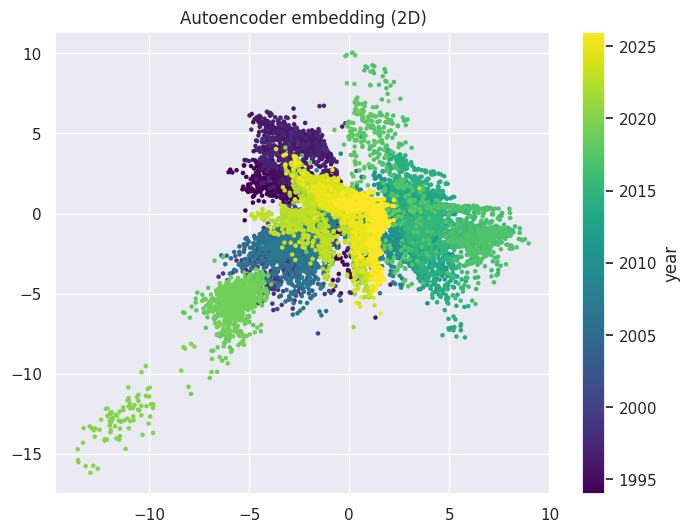

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(Z[:, 0], Z[:, 1], s=5, c=df_clean['year'], cmap='viridis')
plt.colorbar(label='year')
plt.title("Autoencoder embedding (2D)")
plt.show()

#### HDBSCAN

In [23]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    prediction_data=True
)

clusterer.fit(Z)

outlier_scores = clusterer.outlier_scores_

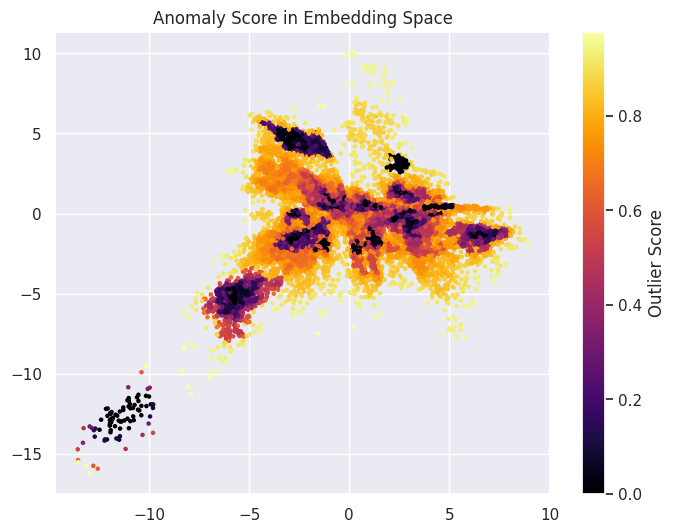

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(Z[:, 0], Z[:, 1], s=5, c=outlier_scores, cmap='inferno')
plt.colorbar(label='Outlier Score')
plt.title('Anomaly Score in Embedding Space')
plt.show()

### ====> Autoencoder + HBSCAN is a way 

In [26]:
df_sample[(df_sample['type']=='std')&(df_sample['label1']==1)].head()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal,year,month,day,hour,minute,seconds,psamp_roll_mean_10,pamb_roll_mean_10,pflow_roll_mean_10,tmod_roll_mean_10,psamp_roll_mean_100,pamb_roll_mean_100,pflow_roll_mean_100,tmod_roll_mean_100,psamp_roll_std_10,pamb_roll_std_10,pflow_roll_std_10,CH4_rt_roll_std_10,psamp_roll_std_100,pamb_roll_std_100,pflow_roll_std_100,CH4_rt_roll_std_100,psamp_diff_1,pflow_diff_1,CH4_area_diff_1,psamp_lag_1,pflow_lag_1
6,940404,31500,std,G-024,G-024,1,0.0,40.0,22.75,NaN,839.6,745.25,NaN,745.5,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.524,NaN,1692.489,F,F,,,1,1,1,940404031500,1994-04-04 03:15:00,False,False,True,True,0.0,False,0.0,NaN,1994-04-04 02:35:00,2400.0,1,0,0,0,0,0,1994-04-03 21:55:00,19200.0,1994,4,4,3,15,0,745.020,745.07,833.89,39.999,760.6877,749.803,839.157,40.0006,0.165193,0.141814,5.442722,0.000000,76.119841,5.086752,13.854083,29.652346,0.00,-10.8,0.0,744.98,828.6
48,940603,155000,std,G-024,G-024,1,0.0,40.0,22.49,NaN,833.3,748.81,NaN,748.8,97.0,7.34,152127.0,1166247.0,1.00,85.4,131.6,30710.0,28689.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940603155000,1994-06-03 15:50:00,False,False,False,False,46.2,False,-2021.0,0.130441,1994-06-03 15:10:00,2400.0,1,0,0,0,0,0,1994-05-29 21:53:00,410220.0,1994,6,3,15,50,0,747.060,747.13,830.77,39.999,742.9949,743.011,825.921,39.9999,0.997475,1.000056,1.143144,1.424235,3.719847,3.708900,3.958759,1.035630,0.40,-1.4,45599.0,748.56,831.1
88,940606,225300,std,G-024,G-024,1,0.0,40.0,23.55,NaN,760.5,758.94,NaN,758.8,94.2,6.67,8287.0,57326.0,1.02,87.0,121.8,26666.0,26375.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.436,NaN,1692.489,F,F,,,1,1,1,940606225300,1994-06-06 22:53:00,False,False,False,False,34.8,False,-291.0,0.144559,1994-06-06 22:13:00,2400.0,1,0,0,0,0,0,1994-06-05 22:12:00,88860.0,1994,6,6,22,53,0,758.652,758.71,800.12,40.003,766.8483,757.768,821.813,40.0015,0.109219,0.152388,42.050493,1.211794,57.024250,0.550276,33.108736,0.991202,0.05,79.3,1298755.0,758.84,839.8
165,941106,141900,std,G-032,G-032,1,0.0,40.0,32.88,NaN,814.0,747.30,NaN,747.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.856,NaN,1679.84,F,F,,,1,1,1,941106141900,1994-11-06 14:19:00,False,False,True,True,0.0,False,0.0,NaN,1994-11-06 13:39:00,2400.0,1,0,0,0,0,0,1994-11-06 12:39:00,6000.0,1994,11,6,14,19,0,730.940,747.25,816.84,39.997,749.2958,747.331,822.048,40.0006,76.327533,0.084984,5.751753,0.000000,50.369350,0.462906,9.436834,44.699872,111.60,0.2,0.0,858.81,813.6
168,941207,163500,std,G-032,G-032,1,0.0,40.0,22.42,NaN,826.8,740.09,NaN,739.9,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.837,NaN,1679.84,F,F,,,1,1,1,941207163500,1994-12-07 16:35:00,False,False,True,True,0.0,False,0.0,NaN,1994-12-07 15:55:00,2400.0,1,0,0,0,0,0,1994-12-04 21:52:00,240180.0,1994,12,7,16,35,0,739.285,739.39,822.80,40.000,741.7093,741.657,824.398,40.0003,0.208713,0.179196,2.558211,50.245902,5.652105,5.629526,6.749889,23.181079,-0.11,-6.7,0.0,739.42,819.0


### try use more data